# Electric Vehicle Purchase Interest — Kaggle Playground S6E9

Predicting the probability that a customer will buy an electric vehicle (`Will_Buy_EV`), evaluated on AUC-ROC.

1. Imports
2. Data loading
3. Exploratory Data Analysis (EDA)
4. Feature preparation
5. Features / target split
6. Train / validation split
7. Preprocessing pipeline
8. Model and training
9. Test predictions and submission

## 1. Imports

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

## 2. Data loading

In [ ]:
# Load the training set
train = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Predicting Electric Vehicle Purchases\train.csv")
print(train.shape)
train.head()

(668665, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [ ]:
# Column types and non-null counts
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Missing values per column
def missing_values_table(df) :
    # Total missing values
    mis_val = df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100*df.isnull().sum() / len(df)

    # Make a table with results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis = 1)

    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(columns ={0:'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,1]!=0].sort_values('% of Total Values', ascending = False).round(1)

    # Print some summary information
    print('Your selected dataframe has ' + str(df.shape[1]) + ' columns.\n'
          'There are ' + str(mis_val_table_ren_columns.shape[0]) + ' columns that have missing values !')

    # Return the dataframe with missing information
    return mis_val_table_ren_columns

missing_values_table(train)

Your selected dataframe has 15 columns.
There are 0 columns that have missing values !


,Missing Values,% of Total Values


In [ ]:
# Check for duplicate rows
train.duplicated().sum()

np.int64(0)

In [ ]:
# Age distribution
train['Age'].describe()

count    668665.000000
mean         47.039171
std          12.875448
min          25.000000
25%          36.000000
50%          47.000000
75%          58.000000
max          69.000000
Name: Age, dtype: float64

In [ ]:
# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Annual income distribution
train['Annual_Income_USD'].describe()

count    668665.000000
mean      84769.266989
std       28648.029042
min       30000.000000
25%       67376.000000
50%       84880.000000
75%      102753.000000
max      188549.000000
Name: Annual_Income_USD, dtype: float64

In [ ]:
# Checking a specific row with a suspicious income value
train.loc[30000, 'Annual_Income_USD']

np.float64(72270.0)

In [ ]:
# Full row inspection
train.iloc[72270]

id                                72270
Age                                  61
Annual_Income_USD               30000.0
Daily_Commute_km                   50.8
Number_of_Cars_Owned                  1
Charging_Stations_Near_Home           3
Charging_Stations_Near_Work           3
Environmental_Concern_Level         3.0
Gender                           Female
City_Type                      Suburban
Current_Car_Type                  Sedan
Home_Charging_Possible              Yes
Subsidy_Available                    No
Range_Anxiety_Level                 Low
Will_Buy_EV                          No
Name: 72270, dtype: object

In [ ]:
# Count of customers with income stuck at exactly 30000
poor = train['Annual_Income_USD'][train['Annual_Income_USD'] == 30000].count()
total = train['Annual_Income_USD'].shape[0]

In [ ]:
# Share of the dataset that represents
pct = (poor/total)*100
print(pct.round(2))

9.21


In [ ]:
# Quick check
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


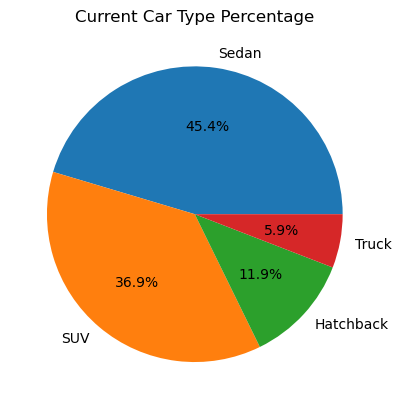

In [ ]:
# Current car type breakdown
plt.pie(train['Current_Car_Type'].value_counts(), autopct="%1.1f%%", labels = train['Current_Car_Type'].value_counts().index)
plt.title('Current Car Type Percentage')
plt.show()

In [ ]:
# City type breakdown
train['City_Type'].value_counts(normalize = True )*100

City_Type
Urban       43.266060
Suburban    38.192069
Rural       18.541871
Name: proportion, dtype: float64

In [ ]:
# Range anxiety level breakdown
train['Range_Anxiety_Level'].value_counts(normalize = True )*100

Range_Anxiety_Level
Low       90.325051
Medium     9.346833
High       0.328116
Name: proportion, dtype: float64

In [ ]:
# Unique values for number of cars owned
train['Number_of_Cars_Owned'].unique()

array([2, 1, 4, 3])

In [ ]:
# Quick check
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


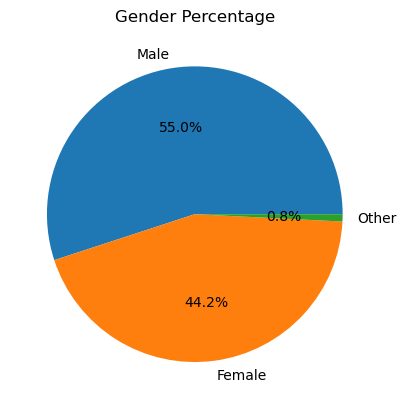

In [ ]:
# Gender breakdown
plt.pie(train['Gender'].value_counts(), autopct="%1.1f%%", labels = train['Gender'].value_counts().index)
plt.title('Gender Percentage')
plt.show()

Text(0.5, 1.0, 'Correlation')

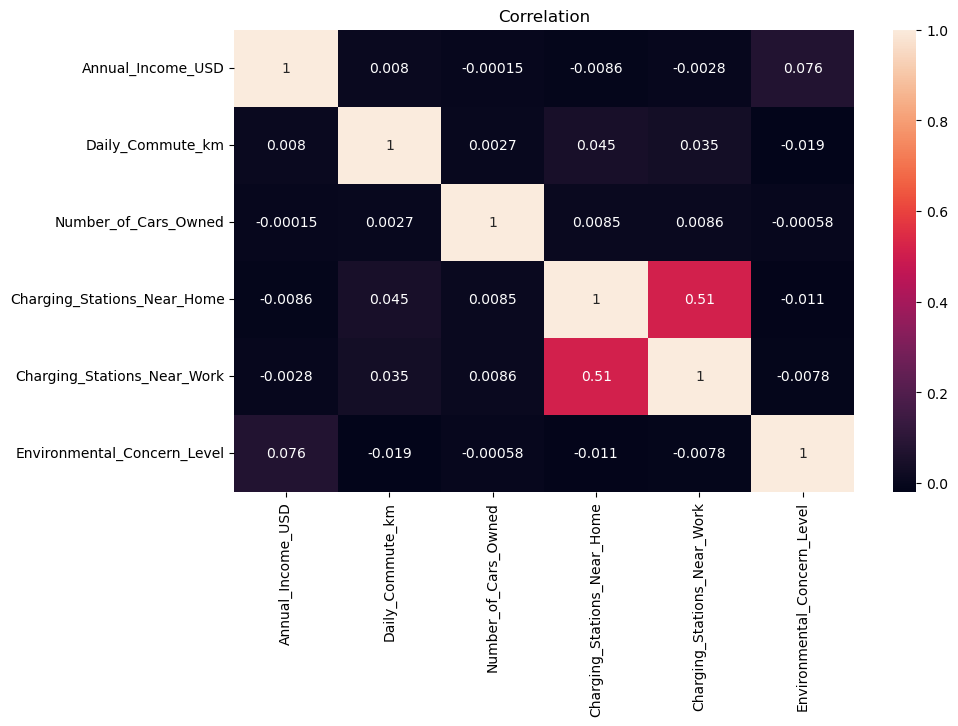

In [ ]:
# Correlation heatmap of the numerical features
corr_cols = train[['Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']]
corr = corr_cols.corr()
fig = plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True)
plt.title('Correlation')

In [ ]:
# Quick check
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## 4. Feature preparation

Manual encoding for binary and ordinal columns:
- `Home_Charging_Possible`, `Subsidy_Available`: Yes/No -> 1/0
- `Range_Anxiety_Level`: ordinal (Low < Medium < High) -> 1/2/3

In [ ]:
# Encode binary and ordinal columns
def data_mapping (df) :
    df['Home_Charging_Possible'] = df['Home_Charging_Possible'].map({'Yes' : 1, 'No' : 0})
    df['Subsidy_Available'] = df['Subsidy_Available'].map({'Yes' : 1, 'No' : 0})
    df['Range_Anxiety_Level'] = df['Range_Anxiety_Level'].map({'Low' : 1, 'Medium' : 2, 'High' : 3})
    return df

## 5. Features / target split

In [ ]:
# Features and traget
data = train.copy()
y = data.Will_Buy_EV
X = data.drop(columns = ['id', 'Will_Buy_EV'])

In [ ]:
# Target: Yes -> 1, No -> 0
y = y.map({'Yes' : 1, 'No' : 0})

In [ ]:
# Quick check
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Will_Buy_EV, dtype: int64

In [ ]:
# Quick check
X.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low


## 6. Train / validation split

In [ ]:
# The Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state = 0)

In [ ]:
# Preprocessing the yes/no columns and the anxiety level
X_train = data_mapping(X_train)
X_val = data_mapping(X_val)

In [ ]:
# Quick check
X_train.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
547925,68,91518.0,5.0,2,0,3,2.0,Male,Suburban,SUV,1,1,1
177491,41,99453.0,43.4,2,7,13,3.0,Male,Urban,SUV,0,1,2
17783,44,154871.0,26.4,2,1,7,5.0,Female,Suburban,Truck,1,1,1
321495,43,77549.0,5.0,2,6,10,2.0,Female,Urban,SUV,0,1,1
171187,47,123547.0,5.0,1,7,9,2.0,Female,Suburban,Sedan,1,0,1


In [ ]:
# Should be [0, 1]
X_train["Home_Charging_Possible"].unique()

array([1, 0])

In [ ]:
# Should be [0, 1]
X_train["Subsidy_Available"].unique()

array([1, 0])

In [ ]:
# Should be [1, 2, 3]
X_train["Range_Anxiety_Level"].unique()

array([1, 2, 3])

## 7. Preprocessing pipeline

One-hot encode the remaining text columns (`Gender`, `City_Type`, `Current_Car_Type`). `remainder='passthrough'` keeps every other column as-is — without it, `ColumnTransformer` would drop them.

In [ ]:
# Detect the remaining text (categorical) columns
# Preprocessing categorical variables
cat_cols = [cname for cname in X_train.columns if X_train[cname].dtypes == 'object']
cat_cols

['Gender', 'City_Type', 'Current_Car_Type']

In [ ]:
# Force column names to string (avoids dtype issues downstream)
X_train.columns = X_train.columns.astype(str)
X_val.columns = X_val.columns.astype(str)

In [ ]:
# scikit-learn preprocessing tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# One-hot encode categorical columns, keep everything else untouched
preprocessor = ColumnTransformer (
    transformers = [
        ('cat', OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'), cat_cols)
    ], remainder = 'passthrough'
)

## 8. Model and training

In [ ]:
# XGBoost classifier
from xgboost import XGBClassifier

In [ ]:
# Model + full pipeline (preprocessing -> model)
model = XGBClassifier(n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1.0,
        eval_metric='auc',
        tree_method='hist',
        random_state=42,
        n_jobs=-1)
pipeline = Pipeline([('prep', preprocessor), ('model', model)])

In [ ]:
# Quick check
X_val.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
613076,31,89539.0,42.4,1,13,13,4.0,Female,Urban,SUV,1,0,1
575212,65,91313.0,5.0,2,3,4,5.0,Male,Suburban,Hatchback,1,1,1
317962,35,30000.0,42.9,1,2,2,4.0,Male,Suburban,Sedan,1,0,1
101364,34,83396.0,46.1,2,0,3,3.0,Female,Suburban,Sedan,1,1,1
190700,68,30000.0,46.2,1,11,8,1.0,Female,Urban,SUV,0,1,1


In [ ]:
# Note: pipeline.predict() returns classes (0/1), not probabilities.
# For an AUC that reflects the model's actual ranking ability, use predict_proba() instead.
from sklearn.metrics import roc_auc_score
pipeline.fit(X_train, y_train)
val_preds = pipeline.predict(X_val)
print('The score is : ', roc_auc_score(y_val, val_preds))

The score is :  0.8084614310974169


In [ ]:
# Predicted classes on validation
val_preds

array([0, 1, 0, ..., 1, 0, 0])

## 9. Test predictions and submission

In [ ]:
# Load the test set
# Importing the test data
test = pd.read_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Predicting Electric Vehicle Purchases\test.csv")
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [ ]:
# Keep the ids for submission, drop from features
test_id = test.id
X_test = test.drop(columns = 'id')

In [ ]:
# Same manual encoding as train/val
X_test = data_mapping(X_test)

In [ ]:
# Quick check
X_test.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,1,0,1
1,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,0,0,1
2,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,0,0,1
3,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,1,0,1
4,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,1,1,1


In [ ]:
# Probability of the positive class, as required by the AUC-ROC metric
final_preds = pipeline.predict_proba(X_test)[:, 1]

In [ ]:
# Quick check
final_preds

array([0.00739128, 0.02009842, 0.00471276, ..., 0.00160037, 0.00061268,
       0.00018686], dtype=float32)

In [ ]:
# Build the submission dataframe
sub = pd.DataFrame({'id' : test_id, 'Will_Buy_EV' : final_preds})

In [ ]:
# Export to csv
sub.to_csv(r"S:\Project Portfolio\Tutorials\Kaggle Competition\Predicting Electric Vehicle Purchases\submission.csv", index = False) 